# Week 3 — Deep Learning Model: Neural Collaborative Filtering

In Week 3, we implement the main deep learning model for the project.

The task is:

```text
Recommendation / Ranking
```

The model predicts a numerical rating for a user-movie pair.

```text
Input: user_index, movie_index
Output: predicted rating
```

In this notebook, we will:

```text
1. Load processed data from Week 2
2. Create PyTorch Dataset and DataLoader
3. Build Neural Collaborative Filtering model
4. Train the model
5. Evaluate the model using RMSE and MAE
6. Compare deep learning results with baseline results
7. Save results and trained model
```

In [2]:
import torch
print(torch.__version__)

2.11.0


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error

## 1. Set Paths and Device

Here we define file paths for processed data, result files, and model files.

We also choose the device for training:

```text
cuda → NVIDIA GPU
mps → Apple Silicon GPU
cpu → normal processor
```

Using GPU can make model training faster.

In [4]:
TRAIN_PATH = "../data/processed/train.csv"
VALID_PATH = "../data/processed/valid.csv"
TEST_PATH = "../data/processed/test.csv"

RESULTS_DIR = "../results"
MODELS_DIR = "../models"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cpu


## 2. Load Processed Data

The Week 3 model uses processed files from Week 2:

```text
data/processed/train.csv
data/processed/valid.csv
data/processed/test.csv
```

These files already contain:

```text
user_index
movie_index
rating
```

The original `userId` and `movieId` were encoded in Week 2.

In [5]:
train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (350000, 6)
Validation shape: (75000, 6)
Test shape: (75000, 6)


,userId,movieId,rating,timestamp,user_index,movie_index
0,112572,4085,3.5,1127647982,86834,3752
1,114217,2791,5.0,938995765,88094,2555
2,112703,6893,4.5,1243932390,86936,6185
3,10573,6552,4.0,1113778981,8223,5905
4,100957,2355,4.0,975474483,77857,2143


## 3. Check Required Columns

For Neural Collaborative Filtering, we need three main columns:

```text
user_index
movie_index
rating
```

`user_index` and `movie_index` are inputs.  
`rating` is the target value.

In [6]:
required_columns = ["user_index", "movie_index", "rating"]

for column in required_columns:
    print(column, "exists in train:", column in train_df.columns)

print("\nRating statistics:")
print(train_df["rating"].describe())

user_index exists in train: True
movie_index exists in train: True
rating exists in train: True

Rating statistics:
count    350000.000000
mean          3.528754
std           1.051144
min           0.500000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


## 4. Get Number of Users and Movies

Embedding layers need to know how many unique users and movies exist.

For example:

```text
num_users = number of unique encoded users
num_movies = number of unique encoded movies
```

These values define the size of the embedding layers.

In [7]:
num_users = int(
    max(
        train_df["user_index"].max(),
        valid_df["user_index"].max(),
        test_df["user_index"].max()
    ) + 1
)

num_movies = int(
    max(
        train_df["movie_index"].max(),
        valid_df["movie_index"].max(),
        test_df["movie_index"].max()
    ) + 1
)

print("Number of users:", num_users)
print("Number of movies:", num_movies)

Number of users: 106761
Number of movies: 13152


## 5. Create PyTorch Dataset

PyTorch Dataset is used to organize data for training.

Each example contains:

```text
user_index
movie_index
rating
```

The Dataset returns one user, one movie, and one rating at a time.

In [8]:
class MovieRatingDataset(Dataset):
    def __init__(self, dataframe):
        self.users = torch.tensor(
            dataframe["user_index"].values,
            dtype=torch.long
        )
        self.movies = torch.tensor(
            dataframe["movie_index"].values,
            dtype=torch.long
        )
        self.ratings = torch.tensor(
            dataframe["rating"].values,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, index):
        return self.users[index], self.movies[index], self.ratings[index]

## 6. Create DataLoaders

DataLoader divides the dataset into batches.

This is important because training on the full dataset at once is not efficient.

```text
batch_size = number of samples processed at one time
shuffle=True for training data
shuffle=False for validation and test data
```

In [9]:
BATCH_SIZE = 4096

train_dataset = MovieRatingDataset(train_df)
valid_dataset = MovieRatingDataset(valid_df)
test_dataset = MovieRatingDataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 86
Validation batches: 19
Test batches: 19


## 7. Build Neural Collaborative Filtering Model

Neural Collaborative Filtering uses embeddings for users and movies.

### Important idea

Instead of using raw IDs directly, the model learns vector representations:

```text
user_index → user embedding vector
movie_index → movie embedding vector
```

Then the model combines both vectors and predicts a rating.

### Model structure

```text
User Embedding
Movie Embedding
Concatenation
Fully Connected Layers
Predicted Rating
```

In [10]:
class NeuralCollaborativeFiltering(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim=64):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.movie_embedding = nn.Embedding(num_movies, embedding_dim)

        self.network = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, user_ids, movie_ids):
        user_vector = self.user_embedding(user_ids)
        movie_vector = self.movie_embedding(movie_ids)

        combined_vector = torch.cat(
            [user_vector, movie_vector],
            dim=1
        )

        predicted_rating = self.network(combined_vector)

        return predicted_rating.squeeze()

## 8. Initialize Model, Loss Function, and Optimizer

### Loss function

We use:

```text
Mean Squared Error Loss
```

because the model predicts numerical ratings.

### Optimizer

We use Adam optimizer because it is commonly used for neural networks and works well in many deep learning tasks.

In [11]:
EMBEDDING_DIM = 64
LEARNING_RATE = 0.001

model = NeuralCollaborativeFiltering(
    num_users=num_users,
    num_movies=num_movies,
    embedding_dim=EMBEDDING_DIM
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(model)

NeuralCollaborativeFiltering(
  (user_embedding): Embedding(106761, 64)
  (movie_embedding): Embedding(13152, 64)
  (network): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 9. Evaluation Function

During training, we evaluate the model using:

```text
RMSE
MAE
```

Predicted ratings are clipped to the valid rating range:

```text
0.5 to 5.0
```

This prevents the model from producing impossible ratings such as `-1` or `6`.

In [12]:
def evaluate_deep_model(model, data_loader):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for users, movies, ratings in data_loader:
            users = users.to(device)
            movies = movies.to(device)
            ratings = ratings.to(device)

            predictions = model(users, movies)

            predictions = predictions.detach().cpu().numpy()
            ratings = ratings.detach().cpu().numpy()

            predictions = np.clip(predictions, 0.5, 5.0)

            all_predictions.extend(predictions)
            all_targets.extend(ratings)

    rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
    mae = mean_absolute_error(all_targets, all_predictions)

    return rmse, mae

## 10. Train the Model

Training steps:

```text
1. Send users, movies, and ratings to device
2. Predict ratings
3. Calculate MSE loss
4. Backpropagate the error
5. Update model weights
6. Evaluate on validation set
```

Validation RMSE and MAE are checked after every epoch.

In [13]:
EPOCHS = 5

train_losses = []
valid_rmse_values = []
valid_mae_values = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for users, movies, ratings in train_loader:
        users = users.to(device)
        movies = movies.to(device)
        ratings = ratings.to(device)

        optimizer.zero_grad()

        predictions = model(users, movies)
        loss = criterion(predictions, ratings)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_train_loss = total_loss / len(train_loader)

    valid_rmse, valid_mae = evaluate_deep_model(model, valid_loader)

    train_losses.append(average_train_loss)
    valid_rmse_values.append(valid_rmse)
    valid_mae_values.append(valid_mae)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {average_train_loss:.4f}")
    print(f"Validation RMSE: {valid_rmse:.4f}")
    print(f"Validation MAE: {valid_mae:.4f}")
    print("-" * 40)

Epoch 1/5
Train Loss: 3.7459
Validation RMSE: 1.0682
Validation MAE: 0.8556
----------------------------------------
Epoch 2/5
Train Loss: 1.2576
Validation RMSE: 1.0335
Validation MAE: 0.8213
----------------------------------------
Epoch 3/5
Train Loss: 1.1744
Validation RMSE: 1.0126
Validation MAE: 0.8013
----------------------------------------
Epoch 4/5
Train Loss: 1.1157
Validation RMSE: 0.9973
Validation MAE: 0.7847
----------------------------------------
Epoch 5/5
Train Loss: 1.0707
Validation RMSE: 0.9879
Validation MAE: 0.7788
----------------------------------------


## 11. Plot Training Loss

This plot shows how the training loss changes across epochs.

If the loss decreases, it means the model is learning from the data.

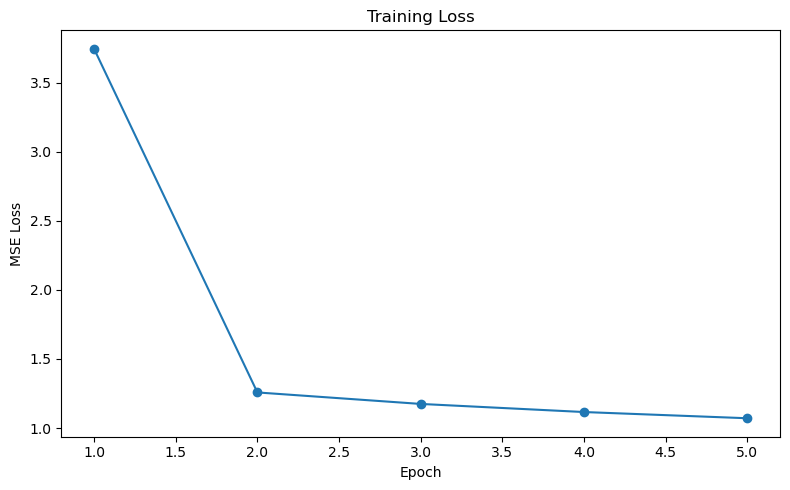

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o"
)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.tight_layout()
plt.savefig("../results/week3_training_loss.png")
plt.show()

## 12. Plot Validation Metrics

This plot shows validation RMSE and MAE.

Lower values mean better prediction quality.

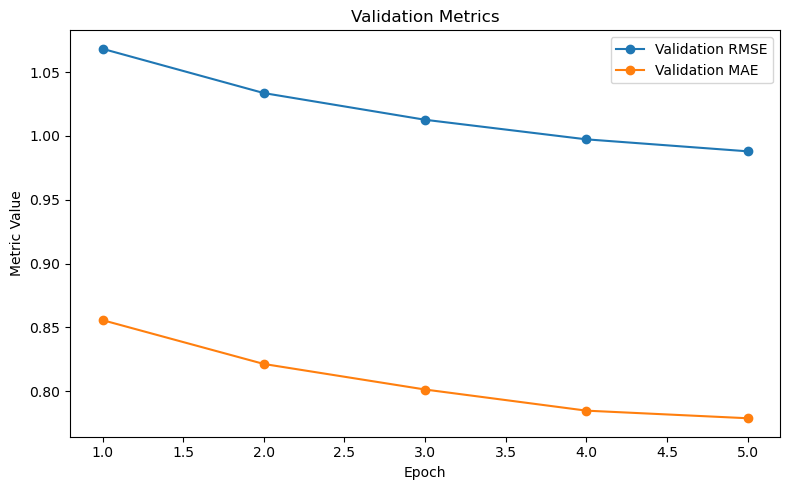

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, EPOCHS + 1),
    valid_rmse_values,
    marker="o",
    label="Validation RMSE"
)
plt.plot(
    range(1, EPOCHS + 1),
    valid_mae_values,
    marker="o",
    label="Validation MAE"
)
plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.legend()
plt.tight_layout()
plt.savefig("../results/week3_validation_metrics.png")
plt.show()

## 13. Final Test Evaluation

The test set is used only after model training.

This gives the final evaluation of the model on unseen data.

In [17]:
test_rmse, test_mae = evaluate_deep_model(
    model,
    test_loader
)

print("Final Test Results")
print("==================")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")

Final Test Results
Test RMSE: 0.9856
Test MAE:  0.7757


## 14. Save Deep Learning Results

The model results are saved for the final report and comparison with the baseline model.

In [18]:
deep_results = pd.DataFrame([
    {
        "model": "Neural Collaborative Filtering",
        "RMSE": test_rmse,
        "MAE": test_mae
    }
])

deep_results.to_csv(
    "../results/week3_deep_learning_results.csv",
    index=False
)

with open("../results/week3_deep_learning_results.txt", "w", encoding="utf-8") as file:
    file.write("Week 3 Deep Learning Model Results\n")
    file.write("=" * 40 + "\n\n")
    file.write(deep_results.to_string(index=False))

print("Deep learning results saved.")

Deep learning results saved.


## 15. Compare with Week 2 Baseline

Here we compare the deep learning model with the baseline models from Week 2.

The best model should have the lowest RMSE and MAE.

In [19]:
baseline_path = "../results/week2_baseline_results.csv"

if os.path.exists(baseline_path):
    baseline_results = pd.read_csv(baseline_path)

    comparison_df = pd.concat(
        [baseline_results, deep_results],
        ignore_index=True
    )

    comparison_df.to_csv(
        "../results/week3_model_comparison.csv",
        index=False
    )

    print("Model comparison:")
    display(comparison_df)
else:
    print("Week 2 baseline results not found.")

Model comparison:


,model,RMSE,MAE
0,Global Average Baseline,1.052172,0.841636
1,Movie Average Baseline,0.957986,0.743593
2,User Average Baseline,1.087004,0.834105
3,Combined User-Movie Average Baseline,0.948204,0.739882
4,Neural Collaborative Filtering,0.985560,0.775673


## 16. Save Trained Model

The trained model is saved so it can be reused later without training again.

In [20]:
model_path = "../models/week3_neural_collaborative_filtering.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "num_users": num_users,
        "num_movies": num_movies,
        "embedding_dim": EMBEDDING_DIM
    },
    model_path
)

print("Model saved to:", model_path)

Model saved to: ../models/week3_neural_collaborative_filtering.pt


## 17. Example Prediction

This example shows one prediction from the test set.

We compare:

```text
real rating
predicted rating
```

In [21]:
example = test_df.iloc[0]

example_user = torch.tensor(
    [example["user_index"]],
    dtype=torch.long
).to(device)

example_movie = torch.tensor(
    [example["movie_index"]],
    dtype=torch.long
).to(device)

model.eval()

with torch.no_grad():
    predicted_rating = model(example_user, example_movie).item()

predicted_rating = np.clip(predicted_rating, 0.5, 5.0)

print("Example Prediction")
print("==================")
print("User index:", example["user_index"])
print("Movie index:", example["movie_index"])
print("Real rating:", example["rating"])
print("Predicted rating:", round(predicted_rating, 2))

Example Prediction
User index: 25710.0
Movie index: 11689.0
Real rating: 2.5
Predicted rating: 2.98


## 18. Save Training History

Training history is useful for analysis. It shows how the model changed during training.

In [22]:
history_df = pd.DataFrame({
    "epoch": list(range(1, EPOCHS + 1)),
    "train_loss": train_losses,
    "valid_rmse": valid_rmse_values,
    "valid_mae": valid_mae_values
})

history_df.to_csv(
    "../results/week3_training_history.csv",
    index=False
)

history_df

,epoch,train_loss,valid_rmse,valid_mae
0,1,3.745927,1.068228,0.855642
1,2,1.257611,1.033540,0.821300
2,3,1.174362,1.012620,0.801279
3,4,1.115679,0.997287,0.784726
4,5,1.070688,0.987909,0.778775


## 19. Final Week 3 Summary

Week 3 completed the main deep learning part of the project.

Created outputs:

```text
training loss plot
validation metrics plot
deep learning results
training history
model comparison
trained model file
```

In [23]:
print("Week 3 completed successfully.")

print("\nCreated result files:")
print("../results/week3_training_loss.png")
print("../results/week3_validation_metrics.png")
print("../results/week3_deep_learning_results.csv")
print("../results/week3_deep_learning_results.txt")
print("../results/week3_training_history.csv")
print("../results/week3_model_comparison.csv")

print("\nCreated model file:")
print("../models/week3_neural_collaborative_filtering.pt")

Week 3 completed successfully.

Created result files:
../results/week3_training_loss.png
../results/week3_validation_metrics.png
../results/week3_deep_learning_results.csv
../results/week3_deep_learning_results.txt
../results/week3_training_history.csv
../results/week3_model_comparison.csv

Created model file:
../models/week3_neural_collaborative_filtering.pt
